# Light-curve reconstructions

Interactive version of `plot_reconstructions.py`. Reuses the same helper functions, so any improvements to the script flow straight through.

Edit the config cell and re-run the rest.

In [3]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Charter", "Bitstream Charter"],
    "font.style": "normal",
})

REPO_ROOT = Path('../..').resolve()
sys.path.insert(0, str(REPO_ROOT / 'scripts'))
sys.path.insert(0, str(REPO_ROOT / 'src'))

from plot_reconstructions import (
    load_model,
    build_lightcurve_index,
    select_examples,
    load_lightcurve,
    compute_flow_predictions,
    generate_block_mask,
    mask_intervals,
)
from lcgen.models.TimeSeriesDataset import METADATA_FEATURES

## Config

Set `gaia_id` or `tic_id` to target a specific star; leave both `None` for random selection.

In [6]:
model_path = str(REPO_ROOT / 'final_model' / 'meta_mask' / 'e15' / 'best_model.pt')
# seq_model_path = str(REPO_ROOT / 'final_model' / 'final_epoch3' / 'model.pt')
# cf_model_path = str(REPO_ROOT / 'output' / 'performance_tests' / 'cf_final' / 'model.pt')
h5_paths = [
    str(REPO_ROOT / 'final_pretrain' / 'timeseries_pretrain.h5'),
    str(REPO_ROOT / 'final_pretrain' / 'timeseries_exop_hosts.h5'),
    str(REPO_ROOT / 'final_pretrain' / 'timeseries_thickdisk.h5'),
]

gaia_id = None
tic_id = None
num_examples = 3
offset = 1
seed = 19
n_flow_samples = 64

# Block-mask params (mirror training-time masking). Set mask_portion=0 to disable.
mask_portion = 0.5
mask_min_size = 5
mask_max_size = 720

# Architecture flags — must match the checkpoint
hidden_size = 64
direction = 'bi'
mode = 'parallel'
use_metadata = True
use_conv_channels = True
conv_encoder_type = 'unet'

In [7]:
np.random.seed(seed)
torch.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

num_meta_features = len(METADATA_FEATURES) if use_metadata else 0
conv_config = None
if use_conv_channels:
    conv_config = {
        'encoder_type': conv_encoder_type,
        'input_length': 2500,
        'encoder_dims': [4, 8, 16, 32],
        'num_layers': 4 if conv_encoder_type == 'unet' else 3,
        'hidden_channels': 16,
        'activation': 'gelu',
    }

model = load_model(model_path, device,
                   hidden_size=hidden_size, direction=direction, mode=mode,
                   num_meta_features=num_meta_features,
                   use_conv_channels=use_conv_channels, conv_config=conv_config)

# Auto-sync feature flags with what the checkpoint actually contains so
# load_lightcurve loads the inputs the model expects.
use_metadata = model.meta_encoder is not None
use_conv_channels = bool(getattr(model, 'use_conv_channels', False))
print(f'(auto-sync) use_metadata={use_metadata} use_conv_channels={use_conv_channels}')

device: cpu
[model] checkpoint has no conv encoders; overriding use_conv_channels -> False
[model] loaded /Users/philvanlane/Documents/lc_ae/final_model/meta_mask/e15/best_model.pt (hidden=64, direction=bi, meta=13, conv=False, flow=True)
(auto-sync) use_metadata=True use_conv_channels=False


In [9]:
index = build_lightcurve_index(h5_paths)
print(f'{len(index)} light curves available across {len(h5_paths)} H5 file(s)')

examples = select_examples(index, gaia_id=gaia_id, tic_id=tic_id,
                           num_examples=num_examples, seed=None)
for ex in examples:
    print(f'  gaia={ex["gaia_id"]} tic={ex["tic_id"]} sector={ex["sector"]} L={ex["length"]}')

69319 light curves available across 3 H5 file(s)
  gaia=5481611101406195584 tic=150431659 sector=27 L=12975
  gaia=4660457919032600704 tic=179234597 sector=38 L=15116
  gaia=2075112109039378688 tic=171882123 sector=81 L=18410


In [8]:
# From previous run
# 60631 light curves available across 2 H5 file(s)
#   gaia=5266642318884581632 tic=176980970 sector=13 L=18986
#   gaia=5656896924435896832 tic=315002523 sector=8 L=12891
#   gaia=2052212996988534656 tic=378085037 sector=40 L=19611

In [10]:
preds_per_example = []
for ex in examples:
    lc = load_lightcurve(ex, use_metadata=use_metadata,
                         use_conv_channels=use_conv_channels, device=device)
    mask = generate_block_mask(ex['length'], mask_min_size, mask_max_size, mask_portion)
    pred_times, median, p16, p84 = compute_flow_predictions(
        model, lc, offset=offset, mask=mask,
        n_samples=n_flow_samples, device=device)
    preds_per_example.append({
        'times':    lc['times'].cpu().numpy(),
        'flux':     lc['flux'].cpu().numpy(),
        'flux_err': lc['flux_err'].cpu().numpy(),
        'pred_times': pred_times,
        'median': median, 'p16': p16, 'p84': p84,
        'mask': mask,
    })
print('done predicting')

done predicting


[save] /Users/philvanlane/Documents/lc_ae/output/reconstructions/reconstructions_seed19_k1.png


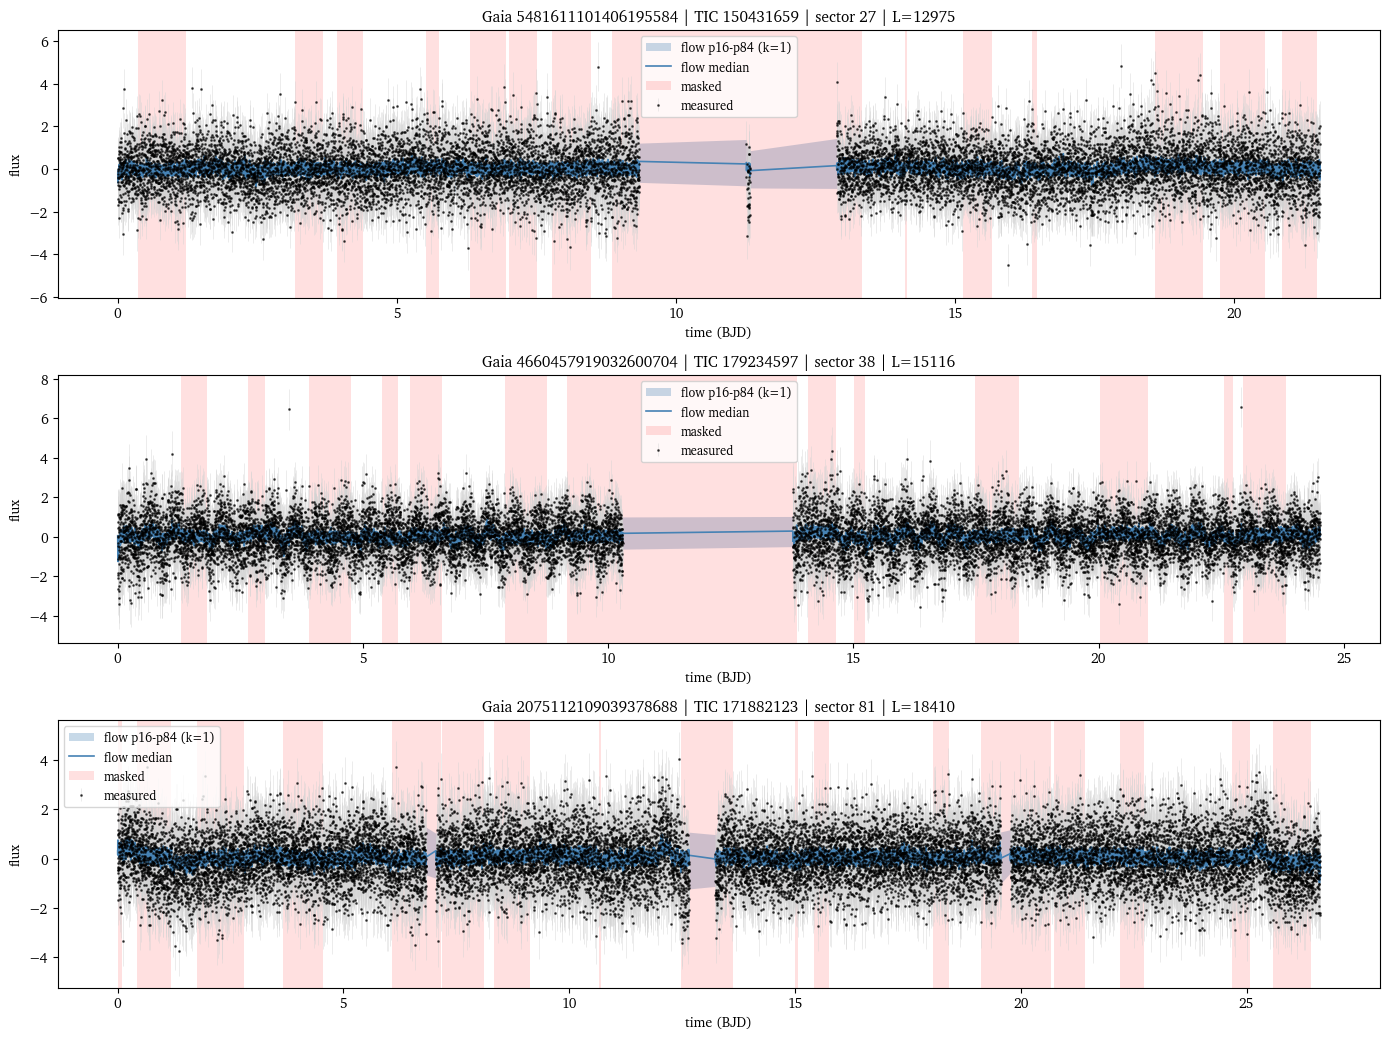

In [11]:
n = len(examples)
fig, axes = plt.subplots(n, 1, figsize=(14, 3.5 * n))
if n == 1:
    axes = [axes]

for ax, entry, pr in zip(axes, examples, preds_per_example):
    ax.errorbar(pr['times'], pr['flux'], yerr=pr['flux_err'],
                fmt='.', color='black', ecolor='lightgray',
                markersize=2, alpha=0.6, elinewidth=0.5, label='measured')
    ax.fill_between(pr['pred_times'], pr['p16'], pr['p84'],
                    color='steelblue', alpha=0.3, linewidth=0,
                    label=f'flow p16-p84 (k={offset})')
    ax.plot(pr['pred_times'], pr['median'],
            color='steelblue', linewidth=1.2, label='flow median')
    mask = pr.get('mask')
    if mask is not None:
        first = True
        for s, e in mask_intervals(mask):
            x0 = pr['times'][s]
            x1 = pr['times'][e - 1] if e > s else x0
            ax.axvspan(x0, x1, color='red', alpha=0.12, linewidth=0,
                       label='masked' if first else None)
            first = False
    ax.set_title(
        f"Gaia {entry['gaia_id']} | TIC {entry['tic_id']} | "
        f"sector {entry['sector']} | L={entry['length']}",
        fontsize=11)
    ax.set_xlabel('time (BJD)')
    ax.set_ylabel('flux')
    ax.legend(loc='best', fontsize=9)

    # To zoom in on a specific region, uncomment and edit:
    # ax.set_xlim(t_min, t_max)
    # ax.set_ylim(f_min, f_max)

fig.tight_layout()

# Save to disk
tag = (f'gaia{gaia_id}' if gaia_id else
       f'tic{tic_id}'   if tic_id   else
       f'seed{seed}')
output_path = Path('.').resolve() / f'reconstructions_{tag}_k{offset}.png'
fig.savefig(output_path, dpi=150, bbox_inches='tight')
print(f'[save] {output_path}')

# plt.xlim(0,0.01)
plt.show()

### Single subplot

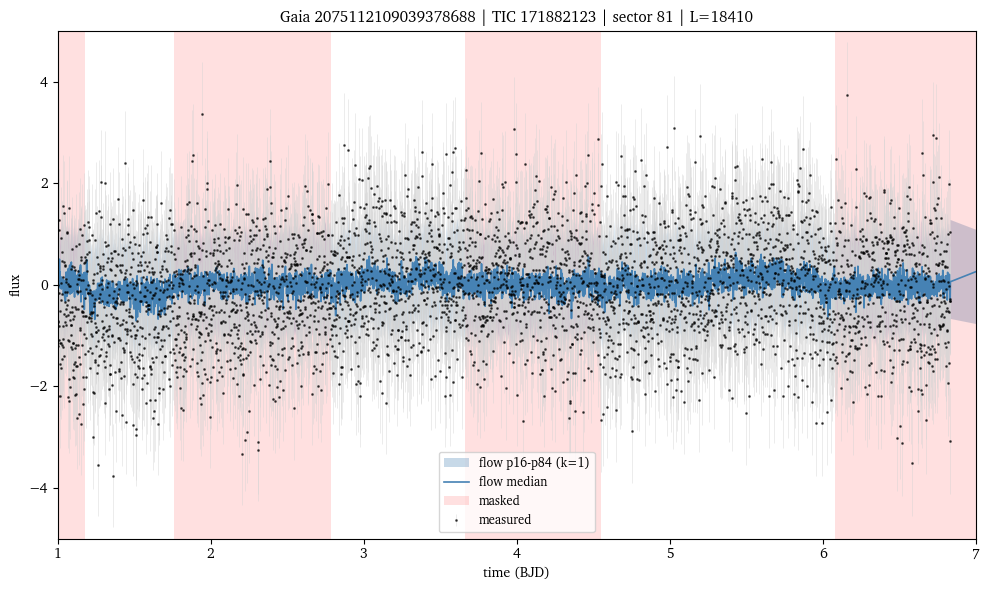

In [12]:
example_idx = 2  # change to plot a different example

entry = examples[example_idx]
pr = preds_per_example[example_idx]

fig, ax = plt.subplots(1, 1, figsize=(10,6))

ax.errorbar(pr['times'], pr['flux'], yerr=pr['flux_err'],
            fmt='.', color='black', ecolor='lightgray',
            markersize=2, alpha=0.6, elinewidth=0.5, label='measured')
ax.fill_between(pr['pred_times'], pr['p16'], pr['p84'],
                color='steelblue', alpha=0.3, linewidth=0,
                label=f'flow p16-p84 (k={offset})')
ax.plot(pr['pred_times'], pr['median'],
        color='steelblue', linewidth=1.2, label='flow median')
mask = pr.get('mask')
if mask is not None:
    first = True
    for s, e in mask_intervals(mask):
        x0 = pr['times'][s]
        x1 = pr['times'][e - 1] if e > s else x0
        ax.axvspan(x0, x1, color='red', alpha=0.12, linewidth=0,
                   label='masked' if first else None)
        first = False
ax.set_title(
    f"Gaia {entry['gaia_id']} | TIC {entry['tic_id']} | "
    f"sector {entry['sector']} | L={entry['length']}",
    fontsize=11)
ax.set_xlabel('time (BJD)')
ax.set_ylabel('flux')
ax.legend(loc='best', fontsize=9)

# To zoom in on a specific region, uncomment and edit:
ax.set_xlim(1,7)
ax.set_ylim(-5,5)

fig.tight_layout()
plt.show()

## Diagnostics

Posterior width / sensitivity tests on the flow head. Two probes:

- **Sections A & B**: scale `flux_err` and see how posterior width responds.
- **Section C**: vary the prediction offset `k` and see whether posterior width grows with horizon.

### Section A — flux_err sweep, one star (qualitative)

Scale `flux_err` by `[0.01, 1.0, 100.0]` (both the RNN input channel and the flow-context input — the same tensor feeds both). The posterior band should widen with the multiplier if the flow is correctly conditioning on measurement error.

  multiplier=   0.1  mean (p84-p16) = 1.2254
  multiplier=   1.0  mean (p84-p16) = 1.9432
  multiplier=  10.0  mean (p84-p16) = 1.6754
[save] /Users/philvanlane/Documents/lc_ae/output/reconstructions/err_sweep_one_star_gaia5481611101406195584_k1.png


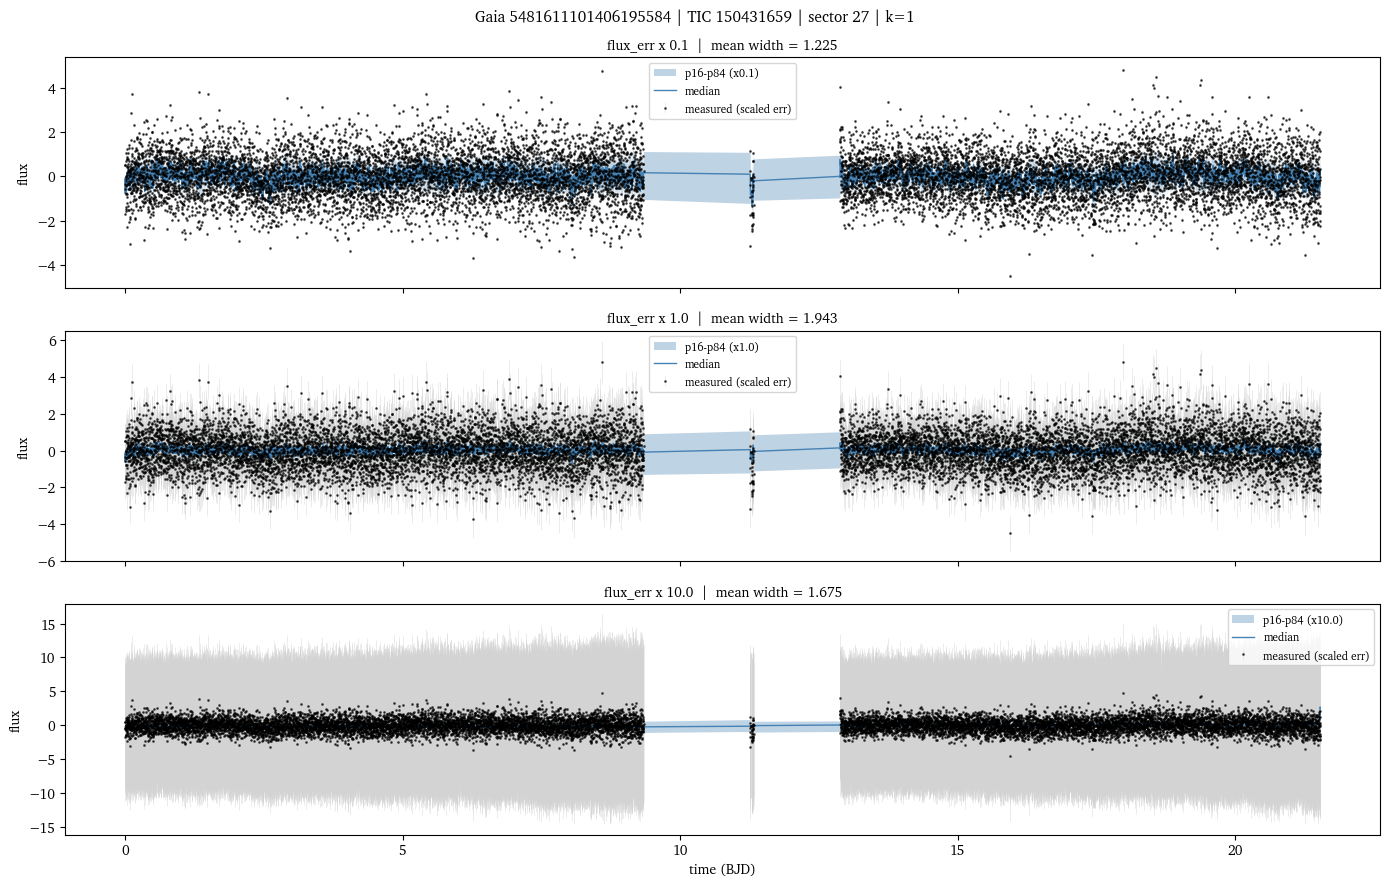

In [13]:
# Section A: flux_err sweep on one star — qualitative
err_multipliers_A = [0.1, 1.0, 10.0]
example_idx_A = 0
offset_A = 1
n_samples_A = 128

entry_A = examples[example_idx_A]
lc_A = load_lightcurve(entry_A, use_metadata=use_metadata,
                      use_conv_channels=use_conv_channels, device=device)
mask_A = generate_block_mask(entry_A['length'], mask_min_size, mask_max_size, 0.0)

preds_A = []
for m in err_multipliers_A:
    lc_scaled = dict(lc_A)
    lc_scaled['flux_err'] = lc_A['flux_err'] * float(m)
    torch.manual_seed(seed)
    pt, med, p16, p84 = compute_flow_predictions(
        model, lc_scaled, offset=offset_A, mask=mask_A,
        n_samples=n_samples_A, device=device)
    preds_A.append({'mult': m, 'pred_times': pt, 'median': med, 'p16': p16, 'p84': p84,
                    'mean_width': float(np.mean(p84 - p16))})
    print(f'  multiplier={m:>6}  mean (p84-p16) = {preds_A[-1]["mean_width"]:.4f}')

fig, axes = plt.subplots(len(err_multipliers_A), 1,
                         figsize=(14, 3.0 * len(err_multipliers_A)), sharex=True)
times_np = lc_A['times'].cpu().numpy()
flux_np  = lc_A['flux'].cpu().numpy()
ferr_np  = lc_A['flux_err'].cpu().numpy()
for ax, p in zip(axes, preds_A):
    ax.errorbar(times_np, flux_np, yerr=ferr_np * p['mult'],
                fmt='.', color='black', ecolor='lightgray',
                markersize=2, alpha=0.6, elinewidth=0.5, label='measured (scaled err)')
    ax.fill_between(p['pred_times'], p['p16'], p['p84'],
                    color='steelblue', alpha=0.35, linewidth=0,
                    label=f"p16-p84 (x{p['mult']})")
    ax.plot(p['pred_times'], p['median'], color='steelblue', linewidth=1.0, label='median')
    ax.set_ylabel('flux')
    ax.set_title(f"flux_err x {p['mult']}  |  mean width = {p['mean_width']:.3f}", fontsize=10)
    ax.legend(loc='best', fontsize=8)
axes[-1].set_xlabel('time (BJD)')
fig.suptitle(
    f"Gaia {entry_A['gaia_id']} | TIC {entry_A['tic_id']} | sector {entry_A['sector']} | k={offset_A}",
    fontsize=11)
fig.tight_layout()
out_path_A = Path('.').resolve() / f"err_sweep_one_star_gaia{entry_A['gaia_id']}_k{offset_A}.png"
fig.savefig(out_path_A, dpi=150, bbox_inches='tight')
print(f'[save] {out_path_A}')
plt.show()


In [14]:
# Diagnostic helpers: forward once per star, sample at multiple k.
# Used by Section B2 (head-only flux_err sweep) and Section C (width vs offset).
def cached_forward(model, lc, device):
    flux = lc['flux'].unsqueeze(0)
    flux_err = lc['flux_err'].unsqueeze(0)
    times = lc['times'].unsqueeze(0)
    L = flux.size(1)
    mask_tensor = torch.ones(1, L, device=device)
    x_in = torch.stack([flux, flux_err], dim=-1)
    t_in = times.unsqueeze(-1)
    meta = lc['metadata'].unsqueeze(0) if lc['metadata'] is not None else None
    conv_data = lc['conv_data']
    with torch.no_grad():
        out = model(x_in, t_in, mask=mask_tensor, metadata=meta,
                    conv_data=conv_data, return_states=True)
    return out, flux_err, times

def predict_at_k_cached(model, out, flux_err, k, n_samples, device):
    h_fwd = out.get('h_fwd_tensor')
    h_bwd = out.get('h_bwd_tensor')
    t_enc = out['t_enc']
    Te = t_enc.size(-1)
    L = flux_err.size(1)
    if 2 * k >= L:
        return None
    n_targets = L - 2 * k
    t_tgt = t_enc[:, k:L-k, :]
    if model.direction == 'bi' and h_fwd is not None and h_bwd is not None:
        H = h_fwd.size(-1)
        src_f = h_fwd[:, :n_targets]
        src_b = h_bwd[:, 2*k:]
        flat_in = torch.cat([src_f, src_b, t_tgt], dim=-1).reshape(-1, 2*H + Te)
    else:
        h = h_fwd if h_fwd is not None else h_bwd
        H = h.size(-1)
        src = h[:, :n_targets]
        flat_in = torch.cat([src, t_tgt], dim=-1).reshape(-1, H + Te)
    with torch.no_grad():
        normed = model.head_norm(flat_in)
        if Te > 0:
            normed = torch.cat([normed[:, :-Te], normed[:, -Te:] * model.time_scale], dim=1)
        ferr_flat = flux_err[:, k:L-k].reshape(-1, 1)
        if model.flow is not None:
            ctx = torch.cat([normed, ferr_flat], dim=1)
            dist = model.flow(ctx)
            samples = torch.stack([dist.sample() for _ in range(n_samples)], dim=0).squeeze(-1)
            median = torch.quantile(samples, 0.5, dim=0).cpu().numpy()
            p16 = torch.quantile(samples, 0.16, dim=0).cpu().numpy()
            p84 = torch.quantile(samples, 0.84, dim=0).cpu().numpy()
        else:
            preds = model.gauss_head(normed).squeeze(-1).cpu().numpy()
            median = preds; p16 = preds; p84 = preds
    return {'median': median, 'p16': p16, 'p84': p84}


#### Zoom in on subset of sequence

### Section B — flux_err sweep, many stars (quantitative)

Mean posterior width vs `flux_err` multiplier on log-log axes. Dashed reference is the slope-1 line you'd see if width tracked `flux_err` directly. Saturation at high multiplier is expected (RNN was trained on a narrow `flux_err` range).

  processed 5/30 stars
  processed 10/30 stars
  processed 15/30 stars
  processed 20/30 stars
  processed 25/30 stars
  processed 30/30 stars
[save] /Users/philvanlane/Documents/lc_ae/output/reconstructions/err_sweep_many_stars.png


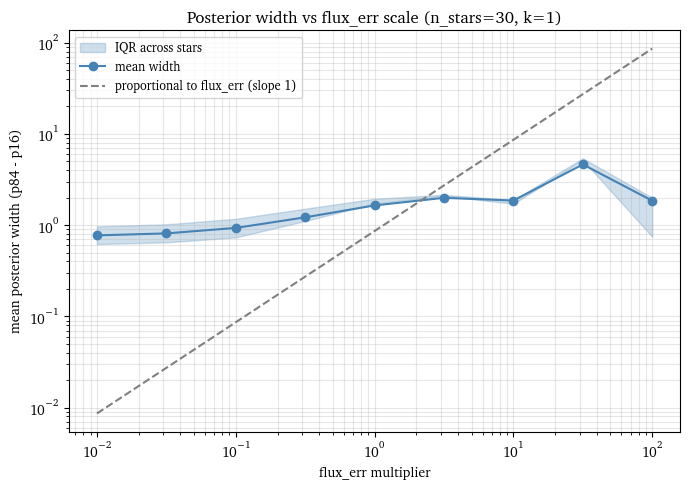

In [15]:
# Section B: flux_err sweep across many stars — quantitative
err_multipliers_B = np.logspace(-2, 2, 9)
n_stars_B = 30
offset_B = 1
n_samples_B = 128
seed_eval_B = 42

rng_B = np.random.default_rng(seed_eval_B)
sel_idx_B = rng_B.choice(len(index), size=n_stars_B, replace=False)
sample_B = [index[int(i)] for i in sel_idx_B]

widths_B = np.full((n_stars_B, len(err_multipliers_B)), np.nan)
ferr_means_B = np.full(n_stars_B, np.nan)
for s, ex in enumerate(sample_B):
    if ex['length'] <= 2 * offset_B:
        continue
    lc_s = load_lightcurve(ex, use_metadata=use_metadata,
                           use_conv_channels=use_conv_channels, device=device)
    mask_s = generate_block_mask(ex['length'], mask_min_size, mask_max_size, 0.0)
    ferr_means_B[s] = float(lc_s['flux_err'].mean().item())
    for j, m in enumerate(err_multipliers_B):
        lc_scaled = dict(lc_s)
        lc_scaled['flux_err'] = lc_s['flux_err'] * float(m)
        torch.manual_seed(seed_eval_B + s)
        _, _, p16, p84 = compute_flow_predictions(
            model, lc_scaled, offset=offset_B, mask=mask_s,
            n_samples=n_samples_B, device=device)
        widths_B[s, j] = float(np.mean(p84 - p16))
    del lc_s
    if (s + 1) % 5 == 0:
        print(f'  processed {s+1}/{n_stars_B} stars')

mean_wB  = np.nanmean(widths_B, axis=0)
p25_wB   = np.nanpercentile(widths_B, 25, axis=0)
p75_wB   = np.nanpercentile(widths_B, 75, axis=0)
mean_ferr_natural = float(np.nanmean(ferr_means_B))

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.fill_between(err_multipliers_B, p25_wB, p75_wB, color='steelblue', alpha=0.25, label='IQR across stars')
ax.plot(err_multipliers_B, mean_wB, marker='o', color='steelblue', label='mean width')
ax.plot(err_multipliers_B, mean_ferr_natural * err_multipliers_B,
        linestyle='--', color='gray', label='proportional to flux_err (slope 1)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('flux_err multiplier')
ax.set_ylabel('mean posterior width (p84 - p16)')
ax.set_title(f'Posterior width vs flux_err scale (n_stars={n_stars_B}, k={offset_B})')
ax.legend(loc='best', fontsize=9)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
out_path_B = Path('.').resolve() / 'err_sweep_many_stars.png'
fig.savefig(out_path_B, dpi=150, bbox_inches='tight')
print(f'[save] {out_path_B}')
plt.show()


### Section B2 — head-only flux_err sweep (many stars)

Same as Section B but `flux_err` is scaled **only in the flow head's context** — the RNN gets the natural `flux_err` so hidden states stay fixed. Overlay shows both curves.

- Both curves flat → flow head itself ignores `flux_err`.
- Head-only flat but Section B sloped → the encoder is the part responding to `flux_err` (unusual — would mean the RNN is rerouting through its second input channel).
- Head-only sloped and roughly matches B → confirms the flow conditions on `flux_err` and the encoder is largely passive w.r.t. that channel.

In [ ]:
# Section B2: flux_err sweep — flow head context only (encoder unaffected)
err_multipliers_B2 = np.logspace(-2, 2, 9)
n_stars_B2 = 30
offset_B2 = 1
n_samples_B2 = 128
seed_eval_B2 = 42

rng_B2 = np.random.default_rng(seed_eval_B2)
sel_idx_B2 = rng_B2.choice(len(index), size=n_stars_B2, replace=False)
sample_B2 = [index[int(i)] for i in sel_idx_B2]

widths_B2 = np.full((n_stars_B2, len(err_multipliers_B2)), np.nan)
ferr_means_B2 = np.full(n_stars_B2, np.nan)
for s, ex in enumerate(sample_B2):
    if ex['length'] <= 2 * offset_B2:
        continue
    lc_s = load_lightcurve(ex, use_metadata=use_metadata,
                           use_conv_channels=use_conv_channels, device=device)
    # Forward pass once with the natural flux_err — encoder is NOT touched by the sweep.
    out_s, ferr_s, _ = cached_forward(model, lc_s, device)
    ferr_means_B2[s] = float(lc_s['flux_err'].mean().item())
    for j, m in enumerate(err_multipliers_B2):
        torch.manual_seed(seed_eval_B2 + s)
        # Scale flux_err only for the head-context path; hidden states stay fixed.
        r = predict_at_k_cached(model, out_s, ferr_s * float(m),
                                offset_B2, n_samples_B2, device)
        if r is None:
            continue
        widths_B2[s, j] = float(np.mean(r['p84'] - r['p16']))
    del lc_s, out_s, ferr_s
    if (s + 1) % 5 == 0:
        print(f'  processed {s+1}/{n_stars_B2} stars')

mean_w2  = np.nanmean(widths_B2, axis=0)
p25_w2   = np.nanpercentile(widths_B2, 25, axis=0)
p75_w2   = np.nanpercentile(widths_B2, 75, axis=0)
mean_ferr_natural_B2 = float(np.nanmean(ferr_means_B2))

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.fill_between(err_multipliers_B2, p25_w2, p75_w2, color='seagreen', alpha=0.25,
                label='IQR across stars (head-only)')
ax.plot(err_multipliers_B2, mean_w2, marker='o', color='seagreen',
        label='mean width (head-only)')
ax.plot(err_multipliers_B2, mean_ferr_natural_B2 * err_multipliers_B2,
        linestyle='--', color='gray', label='proportional to flux_err (slope 1)')
# Overlay Section B's "both" curve for direct comparison if it was run
try:
    ax.plot(err_multipliers_B, mean_wB, marker='s', color='steelblue', alpha=0.7,
            label='mean width (both, Section B)')
except NameError:
    pass
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('flux_err multiplier (head context only)')
ax.set_ylabel('mean posterior width (p84 - p16)')
ax.set_title(f'Head-only flux_err sweep (n_stars={n_stars_B2}, k={offset_B2})')
ax.legend(loc='best', fontsize=9)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
out_path_B2 = Path('.').resolve() / 'err_sweep_head_only_many_stars.png'
fig.savefig(out_path_B2, dpi=150, bbox_inches='tight')
print(f'[save] {out_path_B2}')
plt.show()


  processed 5/30 stars
  processed 10/30 stars
  processed 15/30 stars
  processed 20/30 stars
  processed 25/30 stars


#### Section B2b — single-star head-only flux_err sweep

Same head-only scaling as Section B2 (encoder sees natural `flux_err`), but plot the posterior bands directly on top of the light curve at `0.1x`, `1.0x`, and `10x` the measured `flux_err`. Wider band = head more uncertain when told the measurement is noisier.

  multiplier=  0.1  mean (p84-p16) = 0.7508
  multiplier=  1.0  mean (p84-p16) = 1.0200
  multiplier= 10.0  mean (p84-p16) = 2.8378
[save] /Users/philvanlane/Documents/lc_ae/output/reconstructions/err_sweep_head_only_one_star_gaia5266642318884581632_k1.png


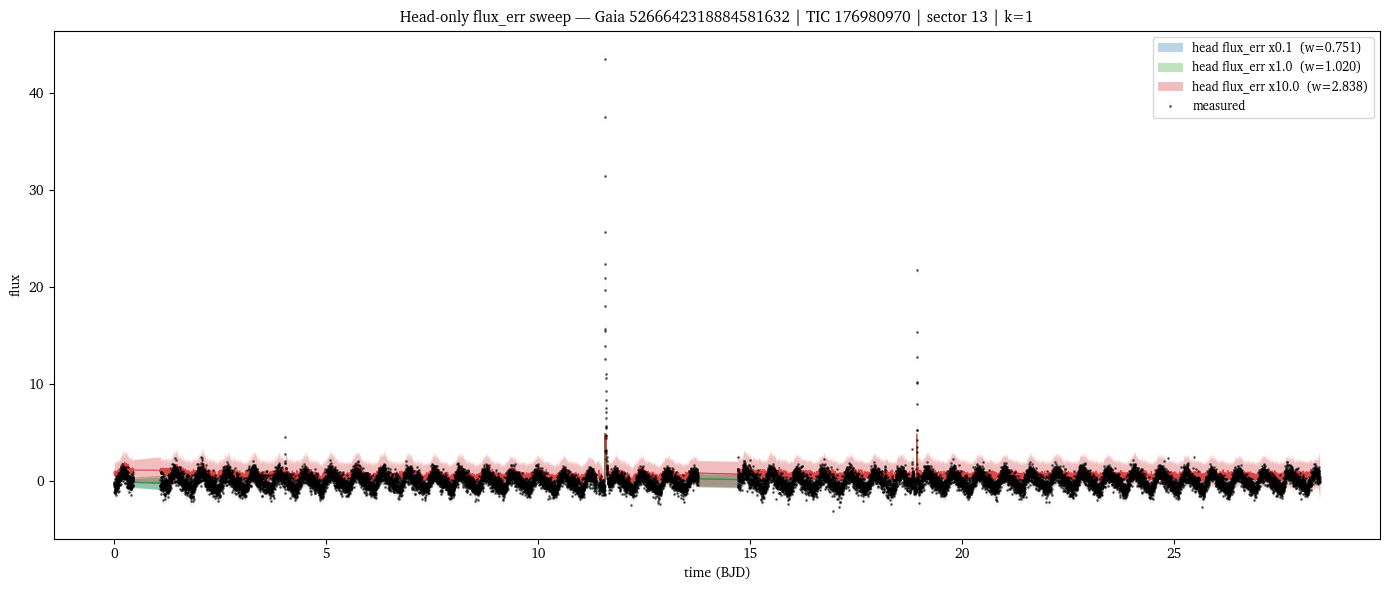

In [226]:
# Section B2b: head-only flux_err sweep — one star, overlay posterior bands
err_multipliers_B2b = [0.1, 1.0, 10.0]
example_idx_B2b = 0
offset_B2b = 1
n_samples_B2b = 128

entry_B2b = examples[example_idx_B2b]
lc_B2b = load_lightcurve(entry_B2b, use_metadata=use_metadata,
                         use_conv_channels=use_conv_channels, device=device)
out_B2b, ferr_B2b, _ = cached_forward(model, lc_B2b, device)
times_np_B2b = lc_B2b['times'].cpu().numpy()
flux_np_B2b  = lc_B2b['flux'].cpu().numpy()
ferr_np_B2b  = lc_B2b['flux_err'].cpu().numpy()
pred_times_B2b = times_np_B2b[offset_B2b:len(times_np_B2b) - offset_B2b]

results_B2b = []
for m in err_multipliers_B2b:
    torch.manual_seed(seed)
    r = predict_at_k_cached(model, out_B2b, ferr_B2b * float(m),
                            offset_B2b, n_samples_B2b, device)
    width = float(np.nanmean(r['p84'] - r['p16']))
    results_B2b.append({'mult': m, **r, 'width': width})
    print(f"  multiplier={m:>5}  mean (p84-p16) = {width:.4f}")

colors_B2b = ['tab:blue', 'tab:green', 'tab:red']
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
ax.errorbar(times_np_B2b, flux_np_B2b, yerr=ferr_np_B2b,
            fmt='.', color='black', ecolor='lightgray',
            markersize=2, alpha=0.5, elinewidth=0.4, label='measured')
for r, c in zip(results_B2b, colors_B2b):
    ax.fill_between(pred_times_B2b, r['p16'], r['p84'],
                    color=c, alpha=0.30, linewidth=0,
                    label=f"head flux_err x{r['mult']}  (w={r['width']:.3f})")
    ax.plot(pred_times_B2b, r['median'], color=c, linewidth=0.8, alpha=0.8)
ax.set_xlabel('time (BJD)')
ax.set_ylabel('flux')
ax.set_title(
    f"Head-only flux_err sweep — Gaia {entry_B2b['gaia_id']} | "
    f"TIC {entry_B2b['tic_id']} | sector {entry_B2b['sector']} | k={offset_B2b}",
    fontsize=11)
ax.legend(loc='best', fontsize=9)
fig.tight_layout()
out_path_B2b = Path('.').resolve() / f"err_sweep_head_only_one_star_gaia{entry_B2b['gaia_id']}_k{offset_B2b}.png"
fig.savefig(out_path_B2b, dpi=150, bbox_inches='tight')
print(f'[save] {out_path_B2b}')
plt.show()


#### Replot for paper

In [231]:
results_B2b[0]

{'mult': 0.1,
 'median': array([-0.3519756 , -0.31867558, -0.3773052 , ...,  0.00313574,
         0.08857584,  0.2526791 ], shape=(18984,), dtype=float32),
 'p16': array([-1.0970585, -0.5909699, -0.6701385, ..., -1.2988344, -1.255719 ,
        -1.7216889], shape=(18984,), dtype=float32),
 'p84': array([ 0.37405592,  0.05890164, -0.045744  , ...,  0.6025669 ,
         0.6599437 ,  1.1094606 ], shape=(18984,), dtype=float32),
 'width': 0.7508096694946289}

In [2]:
len(times_np_B2b)

NameError: name 'times_np_B2b' is not defined

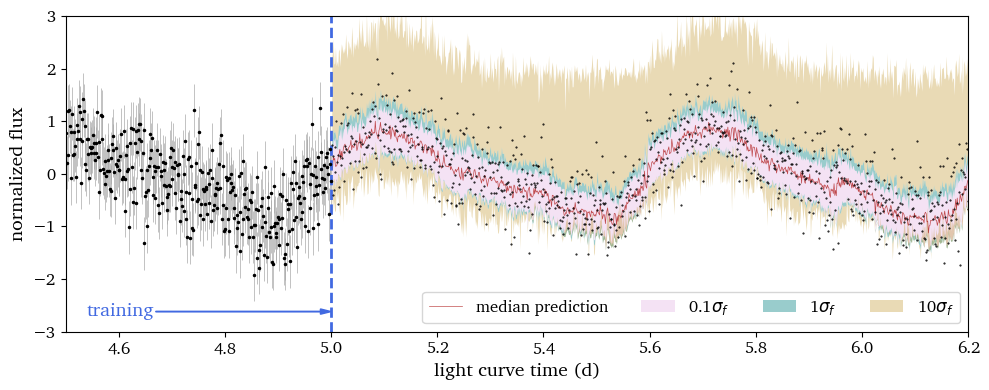

In [280]:
colors_B2b = ['plum', 'teal', 'darkgoldenrod']
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

mask1 = (times_np_B2b >= 5.0) & (times_np_B2b <= 6.2)
mask_train = (times_np_B2b >= 4.5) & (times_np_B2b < 5.0)

ax.errorbar(times_np_B2b[mask_train], flux_np_B2b[mask_train], yerr=ferr_np_B2b[mask_train],
            fmt='.', color='black', ecolor='darkgrey',
            markersize=3, alpha=1, elinewidth=0.5)
ax.errorbar(times_np_B2b[mask1], flux_np_B2b[mask1],
            fmt='.', color='black', ecolor=None,
            markersize=1, alpha=1, elinewidth=0)

xmin, xmax = (5.0,6.2)

# Low flux_err
mask = (pred_times_B2b >= xmin) & (pred_times_B2b <= xmax)
ax.plot(pred_times_B2b[mask], results_B2b[0]['median'][mask], color='firebrick', linewidth=0.5, alpha=0.8,label='median prediction')
ax.fill_between(pred_times_B2b[mask], results_B2b[0]['p16'][mask], results_B2b[0]['p84'][mask],
                color=colors_B2b[0], alpha=0.30, linewidth=0,
                label=r"0.1$\sigma_f$")


# Real flux_err
ax.fill_between(pred_times_B2b[mask], results_B2b[0]['p84'][mask], results_B2b[1]['p84'][mask],
                color=colors_B2b[1], alpha=0.4, linewidth=0)
ax.fill_between(pred_times_B2b[mask], results_B2b[1]['p16'][mask], results_B2b[0]['p16'][mask],
                color=colors_B2b[1], alpha=0.4, linewidth=0,
                label=r"1$\sigma_f$")

# Extra flux_err
ax.fill_between(pred_times_B2b[mask], results_B2b[1]['p84'][mask], results_B2b[2]['p84'][mask],
                color=colors_B2b[2], alpha=0.30, linewidth=0)
ax.fill_between(pred_times_B2b[mask], results_B2b[2]['p16'][mask], results_B2b[1]['p16'][mask],
                color=colors_B2b[2], alpha=0.30, linewidth=0,
                label=r"10$\sigma_f$")




plt.text(4.54,-2.7,'training',fontsize=14, color='royalblue')
plt.arrow(4.67, -2.62, 0.31, 0, color='royalblue', width=0.01, head_width=0.1, head_length=0.02)
plt.axvline(5.0,linestyle='--', color='royalblue',linewidth=2)
ax.set_xlabel('light curve time (d)',fontsize=14)
ax.set_ylabel('normalized flux',fontsize=14)
ax.legend(loc='lower right', fontsize=12, ncol=4)
fig.tight_layout()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(4.5,6.2)
plt.ylim(-3,3)
fig.tight_layout()
plt.show()

In [283]:
# TIC_ID 176980970
# Gaia DR3 ID 5266642318884581632
# Sector 13

In [282]:
print(entry_B2b['tic_id'], entry_B2b['gaia_id'], entry_B2b['sector'])

176980970 5266642318884581632 13


### Section C — Posterior width vs offset k

Does the model become less confident at larger horizons? Expectation: at large `k` the forward source (`h_fwd[j-k]`) and backward source (`h_bwd[j+k]`) are farther from the target on each side, so the flow head should widen its posterior. If width stays flat with `k` and roughly tracks `flux_err`, the flow is leaning on the measurement-error channel and underusing the hidden states.

  k=   1  mean width = 1.0200
  k=   2  mean width = 1.0215
  k=   4  mean width = 1.0253
  k=   8  mean width = 1.0371
  k=  16  mean width = 1.0635
  k=  32  mean width = 1.1265
  k=  64  mean width = 1.2471
  k= 128  mean width = 1.4148
  k= 256  mean width = 1.4888
  k= 512  mean width = 1.6558
[save] /Users/philvanlane/Documents/lc_ae/output/reconstructions/width_vs_k_one_star_gaia5266642318884581632.png


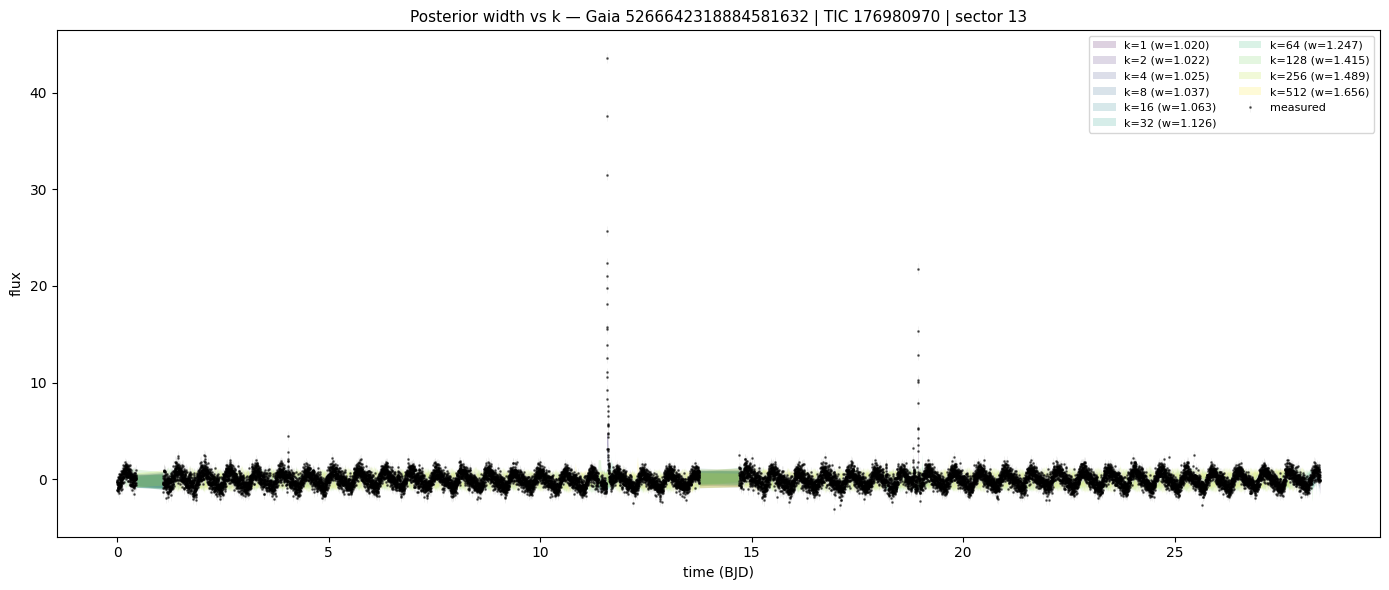

In [64]:
# Section C — one star: overlay posterior bands at multiple k
# K=720 in training (~1 day downlink cadence for TESS 2-min data); 512 is just below that.
k_values_C = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
example_idx_C = 0
n_samples_C = 128

entry_C = examples[example_idx_C]
lc_C = load_lightcurve(entry_C, use_metadata=use_metadata,
                      use_conv_channels=use_conv_channels, device=device)
out_C, ferr_C, _ = cached_forward(model, lc_C, device)
times_np = lc_C['times'].cpu().numpy()
flux_np = lc_C['flux'].cpu().numpy()
ferr_np = lc_C['flux_err'].cpu().numpy()

results_one = []
for k in k_values_C:
    torch.manual_seed(seed)
    r = predict_at_k_cached(model, out_C, ferr_C, k, n_samples_C, device)
    if r is None:
        print(f'  k={k} skipped (sequence too short)')
        continue
    pt = times_np[k:len(times_np)-k]
    width = float(np.mean(r['p84'] - r['p16']))
    results_one.append({'k': k, 'pt': pt, **r, 'width': width})
    print(f'  k={k:>4}  mean width = {width:.4f}')

fig, ax = plt.subplots(1, 1, figsize=(14, 6))
ax.errorbar(times_np, flux_np, yerr=ferr_np, fmt='.', color='black',
            ecolor='lightgray', markersize=2, alpha=0.5, elinewidth=0.4, label='measured')
cmap = plt.get_cmap('viridis')
for i, r in enumerate(results_one):
    c = cmap(i / max(1, len(results_one) - 1))
    ax.fill_between(r['pt'], r['p16'], r['p84'], color=c, alpha=0.18, linewidth=0,
                    label=f"k={r['k']} (w={r['width']:.3f})")
ax.set_xlabel('time (BJD)')
ax.set_ylabel('flux')
ax.set_title(f"Posterior width vs k — Gaia {entry_C['gaia_id']} | TIC {entry_C['tic_id']} | sector {entry_C['sector']}",
             fontsize=11)
ax.legend(loc='best', fontsize=8, ncol=2)
fig.tight_layout()
out_path_c1 = Path('.').resolve() / f"width_vs_k_one_star_gaia{entry_C['gaia_id']}.png"
fig.savefig(out_path_c1, dpi=150, bbox_inches='tight')
print(f'[save] {out_path_c1}')
plt.show()


#### Plotting for paper

In [76]:
len(results_one)

10

In [151]:
results_one

[{'k': 1,
  'pt': array([1.3888767e-03, 2.7777534e-03, 4.1666301e-03, ..., 2.8431713e+01,
         2.8433102e+01, 2.8434490e+01], shape=(18984,), dtype=float32),
  'median': array([-0.20051819, -0.3479367 , -0.36881453, ..., -0.02662766,
          0.04943025,  0.33111572], shape=(18984,), dtype=float32),
  'p16': array([-0.99580926, -0.73653644, -0.786652  , ..., -1.4141742 ,
         -1.3464907 , -1.6785448 ], shape=(18984,), dtype=float32),
  'p84': array([0.5093017 , 0.21618634, 0.15439524, ..., 0.6569742 , 0.6904893 ,
         1.1668968 ], shape=(18984,), dtype=float32),
  'width': 1.0199507474899292},
 {'k': 2,
  'pt': array([2.7777534e-03, 4.1666301e-03, 5.5555068e-03, ..., 2.8430325e+01,
         2.8431713e+01, 2.8433102e+01], shape=(18982,), dtype=float32),
  'median': array([-0.29600415, -0.35985124, -0.53946114, ...,  0.12781054,
          0.16638881,  0.4569031 ], shape=(18982,), dtype=float32),
  'p16': array([-0.9806098 , -0.78473234, -0.98088616, ..., -1.3565108 ,
       

In [152]:
### Set up subsample of data using different k values
idx = [4,9]
results_sub = [results_one[i] for i in idx]

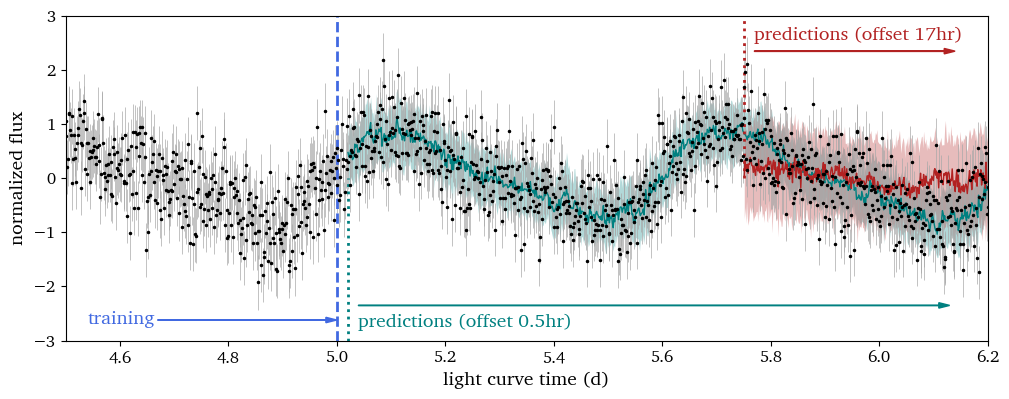

In [281]:
ranges = [
    (5.02, 6.2),
    (5.75, 6.2)
]

colors = ['teal', 'firebrick']

labels = ['0.5hr offset', '17hr offset']

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.errorbar(times_np, flux_np, yerr=ferr_np, fmt='.', color='black',
            ecolor='darkgray', markersize=3, alpha=1, elinewidth=0.5)
cmap = plt.get_cmap('viridis')
for i, r in enumerate(results_sub):
    xmin, xmax = ranges[i]
    mask = (r['pt'] >= xmin) & (r['pt'] <= xmax)
    c = colors[i]  # cmap(i / len(results_sub))
    ax.plot(r['pt'][mask], r['median'][mask], color=c, linewidth=1)
    ax.fill_between(r['pt'], r['p16'], r['p84'], color=c, alpha=0.3, linewidth=0,where=mask,
                    label=labels[i])
    # plt.axvline(xmin, linestyle='--', color=c)
plt.axvline(5.0,linestyle='--', color='royalblue',linewidth=2)
plt.vlines(5.75,0,3,linestyle=':', color='firebrick',linewidth=2)
plt.vlines(5.02,-3,0,linestyle=':', color='teal',linewidth=2)
plt.text(4.54,-2.7,'training',fontsize=14, color='royalblue')
plt.arrow(4.67, -2.62, 0.31, 0, color='royalblue', width=0.01, head_width=0.1, head_length=0.02)
plt.text(5.77, 2.55, 'predictions (offset 17hr)', fontsize=14, color='firebrick')
plt.arrow(5.77, 2.35, 0.35, 0, color='firebrick', width=0.01, head_width=0.1, head_length=0.02)
plt.text(5.04, -2.75, 'predictions (offset 0.5hr)', fontsize=14, color='teal')
plt.arrow(5.04, -2.35, 1.07, 0, color='teal', width=0.01, head_width=0.1, head_length=0.02)
ax.set_xlabel('light curve time (d)',fontsize=14)
ax.set_ylabel('normalized flux',fontsize=14)
# ax.legend(loc='best', fontsize=14, ncol=2)
fig.tight_layout()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(4.5,6.2)
plt.ylim(-3,3)
plt.show()

  processed 5/30 stars
  processed 10/30 stars
  processed 15/30 stars
  processed 20/30 stars
  processed 25/30 stars
  processed 30/30 stars
  skipped 0 stars (length < 2*max_k)
[save] /Users/philvanlane/Documents/lc_ae/output/reconstructions/width_vs_k_many_stars.png


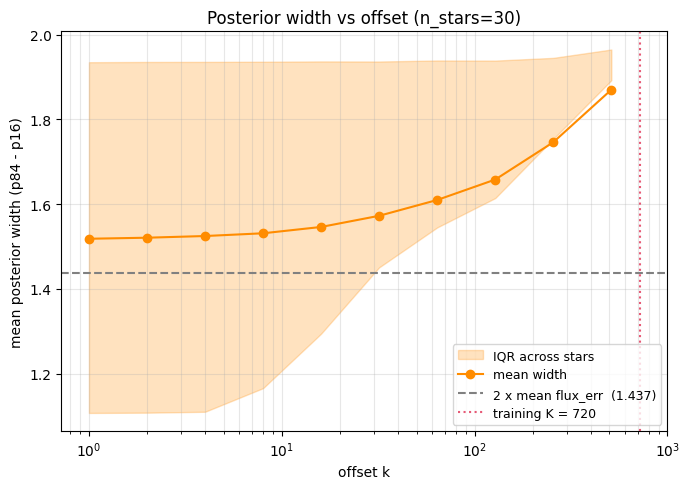

In [65]:
# Section C — many stars: aggregate posterior width vs k
# K=720 in training (~1 day downlink cadence for TESS 2-min data); sweep to 512.
k_values_C2 = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
n_stars_C2 = 30
n_samples_C2 = 128
seed_eval_C2 = 42

rng_C = np.random.default_rng(seed_eval_C2)
sel_idx_C = rng_C.choice(len(index), size=n_stars_C2, replace=False)
sample_C = [index[int(i)] for i in sel_idx_C]

widths_C = np.full((n_stars_C2, len(k_values_C2)), np.nan)
ferr_means_C = np.full(n_stars_C2, np.nan)
skipped = 0
for s, ex in enumerate(sample_C):
    if ex['length'] <= 2 * max(k_values_C2):
        skipped += 1
        continue
    lc_s = load_lightcurve(ex, use_metadata=use_metadata,
                           use_conv_channels=use_conv_channels, device=device)
    out_s, ferr_s, _ = cached_forward(model, lc_s, device)
    ferr_means_C[s] = float(lc_s['flux_err'].mean().item())
    for j, k in enumerate(k_values_C2):
        torch.manual_seed(seed_eval_C2 + s)
        r = predict_at_k_cached(model, out_s, ferr_s, k, n_samples_C2, device)
        if r is None:
            continue
        widths_C[s, j] = float(np.mean(r['p84'] - r['p16']))
    del lc_s, out_s, ferr_s
    if (s + 1) % 5 == 0:
        print(f'  processed {s+1}/{n_stars_C2} stars')
print(f'  skipped {skipped} stars (length < 2*max_k)')

mean_w = np.nanmean(widths_C, axis=0)
p25_w  = np.nanpercentile(widths_C, 25, axis=0)
p75_w  = np.nanpercentile(widths_C, 75, axis=0)
mean_ferr_C = float(np.nanmean(ferr_means_C))

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.fill_between(k_values_C2, p25_w, p75_w, color='darkorange', alpha=0.25, label='IQR across stars')
ax.plot(k_values_C2, mean_w, marker='o', color='darkorange', label='mean width')
ax.axhline(mean_ferr_C * 2, linestyle='--', color='gray',
           label=f'2 x mean flux_err  ({2*mean_ferr_C:.3f})')
ax.axvline(720, linestyle=':', color='crimson', alpha=0.7, label='training K = 720')
ax.set_xscale('log')
ax.set_xlabel('offset k')
ax.set_ylabel('mean posterior width (p84 - p16)')
ax.set_title(f'Posterior width vs offset (n_stars={n_stars_C2 - skipped})')
ax.legend(loc='best', fontsize=9)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
out_path_cm = Path('.').resolve() / 'width_vs_k_many_stars.png'
fig.savefig(out_path_cm, dpi=150, bbox_inches='tight')
print(f'[save] {out_path_cm}')
plt.show()
